In [1]:
import warnings
warnings.filterwarnings("ignore")

### 1.Import Data 

In [2]:
from src.data.data import CTScanFolderDataset
from src.transforms.ct_transforms import get_train_transforms,get_eval_transforms

train_transform = get_train_transforms(224)
val_transform = get_eval_transforms(224)

trainDataSet = CTScanFolderDataset("data/train",train_transform)
testDataSet = CTScanFolderDataset("data/test",val_transform)
validDataSet = CTScanFolderDataset("data/valid",val_transform)

print("Number of train samples:", len(trainDataSet))
print("Number of test samples:", len(testDataSet))
print("Number of validation samples:", len(validDataSet))

print("Classes:", trainDataSet.classes)
print("Mapping:", trainDataSet.class_to_idx)

sample = trainDataSet[0]
print(sample["image"].shape)
print(sample["label"])

Number of train samples: 613
Number of test samples: 315
Number of validation samples: 72
Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Mapping: {'adenocarcinoma': 0, 'large.cell.carcinoma': 1, 'normal': 2, 'squamous.cell.carcinoma': 3}
torch.Size([3, 224, 224])
0


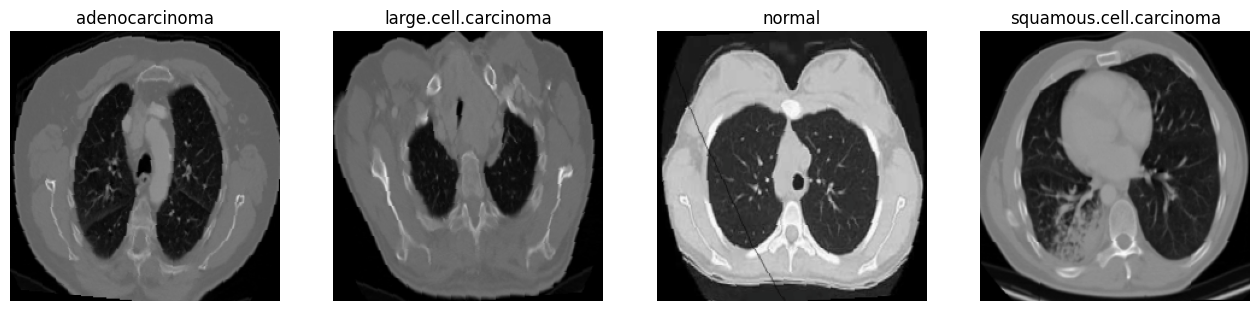

In [3]:
from src.plot.plot import plot_one_image_per_class

plot_one_image_per_class(trainDataSet)

In [4]:
from src.data.dataLoader import create_dataloaders

train_loader, valid_loader, test_loader, classes = create_dataloaders(
    train_dir="data/train",
    valid_dir="data/valid",
    test_dir="data/test",
    image_size=224,
    batch_size=32,
    num_workers=0
)

batch = next(iter(train_loader))

images = batch["image"]
labels = batch["label"]

print("Classes:", classes)
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Classes: ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']
Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([2, 0, 0, 1, 2, 3, 2, 2, 3, 1, 2, 3, 0, 0, 1, 0, 1, 3, 2, 2, 0, 0, 1, 0,
        2, 3, 2, 3, 0, 1, 2, 3])


### 2. Check Class Imbalance

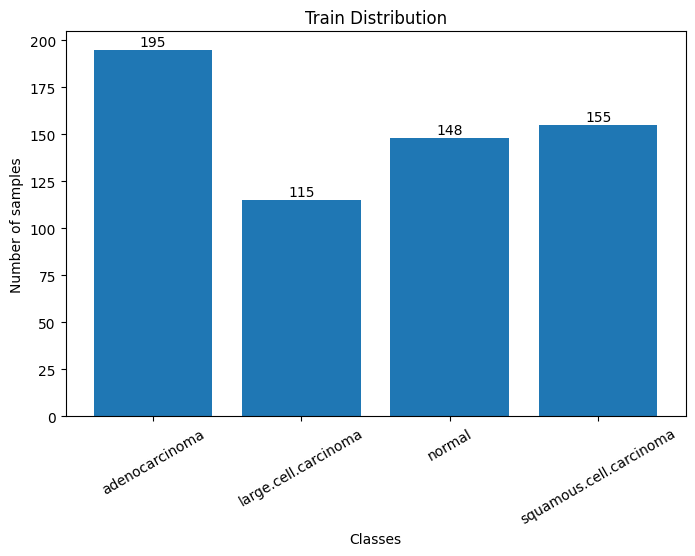

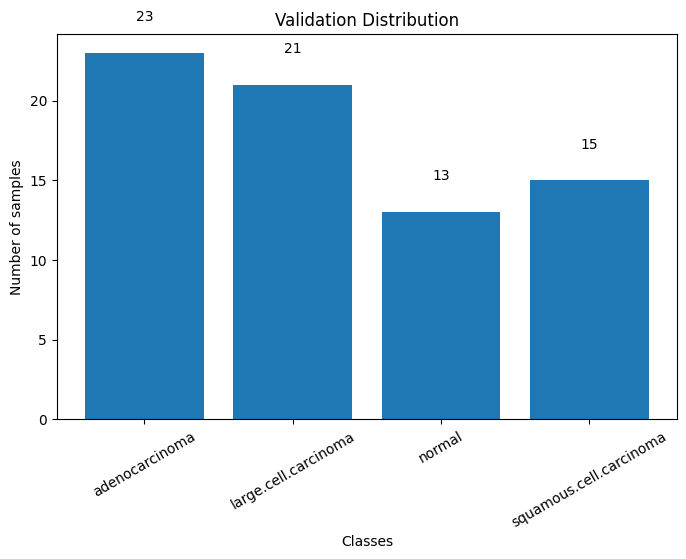

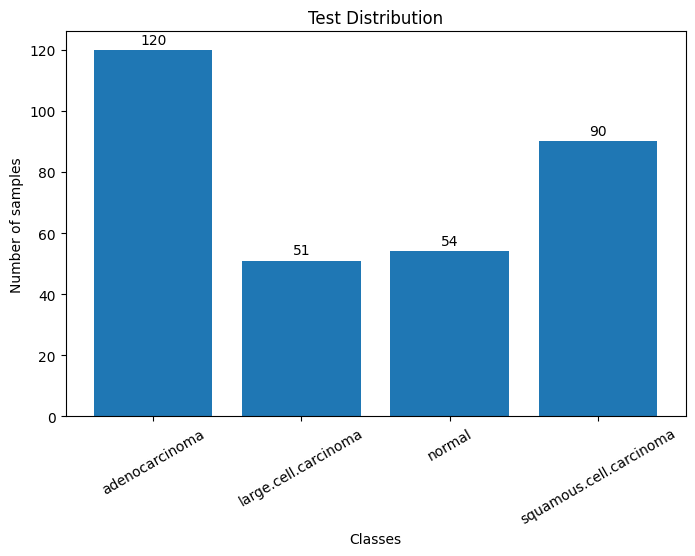

In [5]:
from src.plot.plot import plot_class_distribution

plot_class_distribution(trainDataSet, "Train Distribution")
plot_class_distribution(validDataSet, "Validation Distribution")
plot_class_distribution(testDataSet, "Test Distribution")

In [6]:
import torch
from src.model.cnn_baseline import CNNBaseline

model = CNNBaseline(num_classes=4)

batch = next(iter(train_loader))
images = batch["image"]

outputs = model(images)

print(outputs.shape)

torch.Size([32, 4])


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.model.cnn_baseline import CNNBaseline
from src.training.training import train_one_epoch, validate_one_epoch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNBaseline(num_classes=4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    valid_loss, valid_acc = validate_one_epoch(
        model, valid_loader, criterion, device
    )

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Valid Loss: {valid_loss:.4f} | Valid Acc: {valid_acc:.4f}")


Epoch 1/10


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.52it/s]


Train Loss: 1.3604 | Train Acc: 0.4095
Valid Loss: 1.2241 | Valid Acc: 0.3889

Epoch 2/10


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.47it/s]


Train Loss: 1.1726 | Train Acc: 0.4323
Valid Loss: 1.1162 | Valid Acc: 0.4583

Epoch 3/10


...

Train Loss: 0.9406 | Train Acc: 0.5383
Valid Loss: 0.9420 | Valid Acc: 0.5417

Epoch 9/10


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.41it/s]


Train Loss: 0.9667 | Train Acc: 0.5155
Valid Loss: 0.9272 | Valid Acc: 0.5000

Epoch 10/10


Validation: 100%|██████████| 3/3 [00:00<00:00,  3.46it/s]

Train Loss: 0.8982 | Train Acc: 0.5579
Valid Loss: 0.9532 | Valid Acc: 0.4861


In [8]:
print("Total params:", model.count_parameters())
print("Trainable params:", model.count_trainable_parameters())

Total params: 3305124
Trainable params: 3305124


Evaluating: 100%|██████████| 3/3 [00:01<00:00,  2.81it/s]


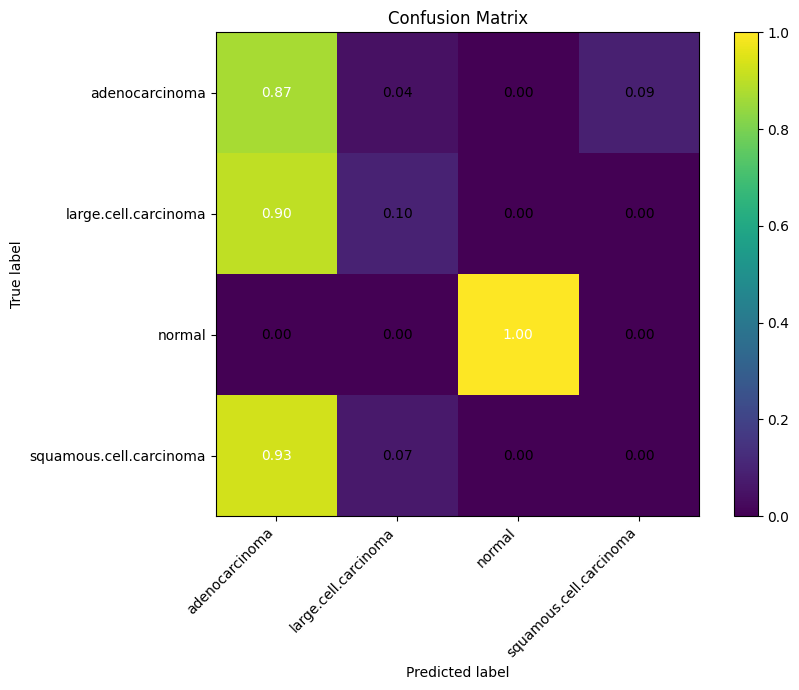

                         precision    recall  f1-score   support

         adenocarcinoma       0.38      0.87      0.53        23
   large.cell.carcinoma       0.50      0.10      0.16        21
                 normal       1.00      1.00      1.00        13
squamous.cell.carcinoma       0.00      0.00      0.00        15

               accuracy                           0.49        72
              macro avg       0.47      0.49      0.42        72
           weighted avg       0.45      0.49      0.40        72

[[20  1  0  2]
 [19  2  0  0]
 [ 0  0 13  0]
 [14  1  0  0]]


KeyError: 'specificity_per_class'

In [9]:
from src.evaluation.evaluate import evaluate_model

metrics = evaluate_model(
    model=model,
    data_loader=valid_loader,
    device=device,
    class_names=classes
)

print(metrics["classification_report"])
print(metrics["confusion_matrix"])
print("Specificity per class:", metrics["specificity_per_class"])